# LLM Comparison

This notebook analyzes the results of three models (gpt-5.1, claude-sonnet-4.5 and DeepSeek-R1-mga) in molecule optimization experiments:

**Task**
- Number of random pubchem molecules: 20
- Min similarity: 0.7
- Min QED: 0.7
- Target score: 0.9
- Max iterations: 51
- Temperature: 0.0
- Repetitions per molecule: 1

additionally two different XAI (explanation) settings:
- **Full XAI**: Complete explanations for all oracles
- **No XAI**: No explanations provided

In [13]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [14]:
# Define paths
RESULTS_DIR = Path("../data/results/similarity_qed_pubchem")

In [15]:
# Define experiment groups: (model, xai_mode, folder_name)
GROUPS = [
    ("claude-sonnet-4.5", "full_xai", "claude-sonnet-4.5_full_xai"),
    #("claude-sonnet-4.5", "no_xai", "claude-sonnet-4.5_no_xai"),
    ("claude-opus-4.5", "full_xai", "claude-opus-4.5_full_xai"),
    #("claude-opus-4.5", "no_xai", "claude-opus-4.5_no_xai"),
    ("gpt-5.1", "full_xai", "gpt-5.1_full_xai"),
    #("gpt-5.1", "no_xai", "gpt-5.1_no_xai"),
    ("gpt-4.1", "full_xai", "gpt-4.1_full_xai"),
    #("gpt-4.1", "no_xai", "gpt-4.1_no_xai"),
    #("DeepSeek-R1-mga", "full_xai", "DeepSeek-R1-mga_full_xai"),
]

def load_trace(p):
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d

# Load all data into a single DataFrame
rows = []
for model, xai_mode, folder in GROUPS:
    files = sorted((RESULTS_DIR / folder).glob("sim_qed_pubchem_*.json"))
    if not files:
        raise FileNotFoundError(f"No files in {RESULTS_DIR/folder} matching sim_qed_pubchem_*.json")
    
    for file_idx, file_path in enumerate(files):
        # Extract target molecule (e.g., "mol1", "mol2") from filename
        mol_match = re.search(r'mol\d+', file_path.name)
        target_molecule = mol_match.group() if mol_match else f"mol{file_idx}"
        
        trace = load_trace(file_path)
        for entry in trace:
            rows.append({
                "model": model,
                "xai_mode": xai_mode,
                "target_molecule": target_molecule,
                "iteration": int(entry["iteration"]),
                "score": float(entry["score"]),
                "smiles": entry["smiles"],
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} models")
df.head(10)


Loaded 3881 rows from 4 models


,model,xai_mode,target_molecule,iteration,score,smiles
0,claude-sonnet-4.5,full_xai,mol10,1,0.639876,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1
1,claude-sonnet-4.5,full_xai,mol10,2,0.774726,Cc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C)cc1
2,claude-sonnet-4.5,full_xai,mol10,3,0.171036,CCCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)c2...
3,claude-sonnet-4.5,full_xai,mol10,4,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
4,claude-sonnet-4.5,full_xai,mol10,5,0.735445,CCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C2C...
5,claude-sonnet-4.5,full_xai,mol10,6,0.772393,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)C)cc1
6,claude-sonnet-4.5,full_xai,mol10,7,0.171036,CCCc1nn(-c2ccccc2C)c(OC(C)=O)c1-c1ccc(NC(=O)c2...
7,claude-sonnet-4.5,full_xai,mol10,8,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
8,claude-sonnet-4.5,full_xai,mol10,9,0.794607,CCc1nn(C)c(OC(=O)C)c1-c1ccc(NC(=O)c2cccs2)cc1
9,claude-sonnet-4.5,full_xai,mol10,10,0.769309,CCc1nn(C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1


Text(0.5, 1.0, 'Best-so-far progression (LLMs only)')

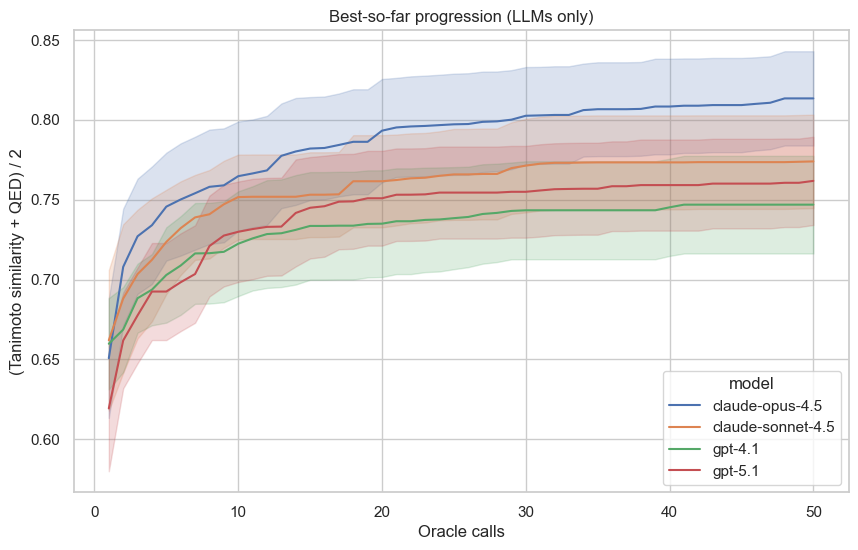

In [16]:
# Compute best-so-far (cummax needs data sorted by iteration)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "xai_mode", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
all_iterations = range(1, df["iteration"].max() + 1)
df_plot = (
    df.pivot_table(index="iteration", columns=["model", "xai_mode", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% CI, deterministic via SE * 1.96)
sns.lineplot(data=df_plot, x="iteration", y="value", hue="model", errorbar=('se', 1.96))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.title("Best-so-far progression (LLMs only)")

(0.0, 1.0)

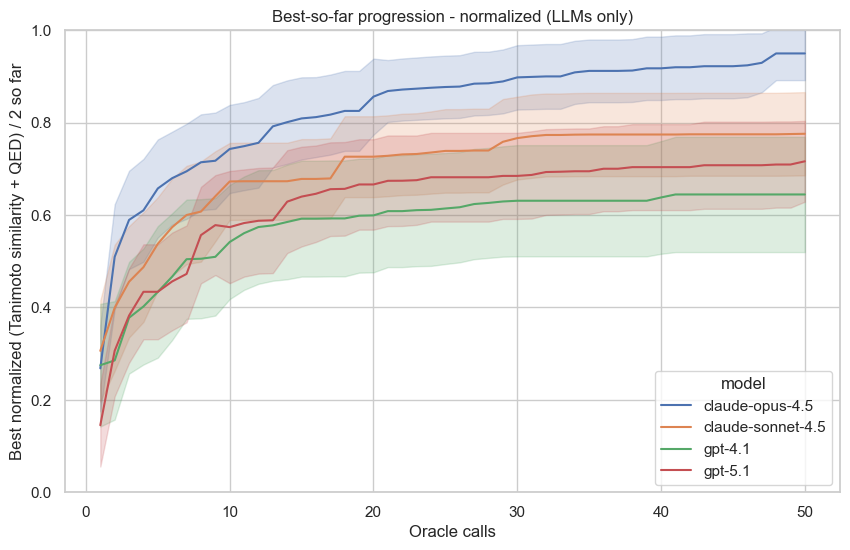

In [17]:
df_norm = df.copy()

# Compute min and max of best_so_far for each target molecule (across all models)
target_stats = df.groupby("target_molecule")["best_so_far"].agg(["min", "max"])
target_stats["range"] = target_stats["max"] - target_stats["min"]

# Merge stats back and normalize best_so_far directly
df_norm = df_norm.merge(target_stats, on="target_molecule")
df_norm["best_so_far_normalized"] = (df_norm["best_so_far"] - df_norm["min"]) / df_norm["range"]

# Pivot and plot (same approach as before)
all_iterations = range(1, df_norm["iteration"].max() + 1)
df_plot_norm = (
    df_norm.pivot_table(index="iteration", columns=["model", "xai_mode", "target_molecule"], values="best_so_far_normalized")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% CI, deterministic via SE * 1.96)
sns.lineplot(data=df_plot_norm, x="iteration", y="value", hue="model", errorbar=('se', 1.96))
plt.xlabel("Oracle calls")
plt.ylabel("Best normalized (Tanimoto similarity + QED) / 2 so far")
plt.title("Best-so-far progression - normalized (LLMs only)")
plt.ylim(0, 1)

## Load Reinvent Baseline Results

The Reinvent baseline uses a different file format (YAML) and stores results differently.
Each molecule folder contains a YAML file with SMILES as keys and [score, step_number] as values.

In [18]:
import yaml

REINVENT_DIR = Path("../data/results/reinvent/random_molecules_sim_qed")

def load_reinvent_results(reinvent_dir: Path) -> pd.DataFrame:
    """Load Reinvent baseline results from YAML files.
    
    Each YAML file has SMILES as keys and [score, step_number] as values.
    We need to reconstruct iteration-wise best scores from the step numbers.
    """
    rows = []
    
    for mol_dir in sorted(reinvent_dir.glob("mol_*")):
        yaml_files = list(mol_dir.glob("results_reinvent_*.yaml"))
        if not yaml_files:
            continue
            
        yaml_file = yaml_files[0]
        target_molecule = mol_dir.name.replace("_", "")  # "mol_1" -> "mol1"
        
        with open(yaml_file, 'r') as f:
            data = yaml.safe_load(f)
        
        # Parse the YAML: keys are SMILES, values are [score, step_number]
        mol_results = []
        for smiles, values in data.items():
            score = values[0]
            step = values[1]
            mol_results.append({
                "smiles": smiles,
                "score": score,
                "step": step,
                "target_molecule": target_molecule,
            })
        
        # Sort by step number and compute iteration (1-indexed)
        mol_df = pd.DataFrame(mol_results).sort_values("step")
        mol_df["iteration"] = range(1, len(mol_df) + 1)
        
        for _, row in mol_df.iterrows():
            rows.append({
                "model": "Reinvent",
                "xai_mode": "baseline",
                "target_molecule": row["target_molecule"],
                "iteration": row["iteration"],
                "score": row["score"],
                "smiles": row["smiles"],
            })
    
    return pd.DataFrame(rows)

# Load Reinvent data
df_reinvent = load_reinvent_results(REINVENT_DIR)
print(f"Loaded {len(df_reinvent)} rows from Reinvent baseline")
print(f"Target molecules: {df_reinvent['target_molecule'].nunique()}")
print(f"Iterations per molecule: {df_reinvent.groupby('target_molecule')['iteration'].max().describe()}")
df_reinvent.head(10)

Loaded 20020 rows from Reinvent baseline
Target molecules: 20
Iterations per molecule: count      20.0
mean     1001.0
std         0.0
min      1001.0
25%      1001.0
50%      1001.0
75%      1001.0
max      1001.0
Name: iteration, dtype: float64


,model,xai_mode,target_molecule,iteration,score,smiles
0,Reinvent,baseline,mol1,1,0.198832,Cn1cc(C(C)(C)C)cc1/C=C(\C#N)C(=O)c1ccc([N+](=O...
1,Reinvent,baseline,mol1,2,0.499546,NC(=O)c1ccc(CSCc2ccccc2)nc1
2,Reinvent,baseline,mol1,3,0.404276,CN(Cc1ccccc1O)C(=O)N[C@@H](Cc1ccccc1)c1ccccn1
3,Reinvent,baseline,mol1,4,0.389506,COC(=O)[C@@H](C)Sc1nc2ccc(Cl)cc2n1CC(=O)[O-]
4,Reinvent,baseline,mol1,5,0.497607,O=C(/C=C/SCc1cccnc1)Nc1cc(C(F)(F)F)ccc1Cl
5,Reinvent,baseline,mol1,6,0.504678,Cc1ocnc1CNC(=O)N1CCCCC[C@@H]1c1cccn1C
6,Reinvent,baseline,mol1,7,0.341852,O=C(NCc1ccccn1)c1ccccc1NC(=S)NCc1ccco1
7,Reinvent,baseline,mol1,8,0.388157,CC[NH+]1CCN(c2ncnc(N)c2O)[C@H](C(C)C)C1
8,Reinvent,baseline,mol1,9,0.448412,Cc1cccc(C2=NN=C[C@H]2COC(=O)c2ccco2)c1
9,Reinvent,baseline,mol1,10,0.477724,CCCCN1C(=O)Cc2ccc(NC(=O)C(=O)N3CCCCCC3)cc21


In [19]:
# Combine LLM results with Reinvent baseline
df_combined = pd.concat([df, df_reinvent], ignore_index=True)

# Compute best-so-far for the combined dataframe
df_combined["best_so_far"] = (
    df_combined.sort_values("iteration")
    .groupby(["model", "xai_mode", "target_molecule"])["score"]
    .cummax()
)

print(f"Combined dataset: {len(df_combined)} rows")
print(f"Models: {df_combined['model'].unique()}")
print(f"Max iterations per model:")
print(df_combined.groupby("model")["iteration"].max())

Combined dataset: 23901 rows
Models: ['claude-sonnet-4.5' 'claude-opus-4.5' 'gpt-5.1' 'gpt-4.1' 'Reinvent']
Max iterations per model:
model
Reinvent             1001
claude-opus-4.5        50
claude-sonnet-4.5      50
gpt-4.1                50
gpt-5.1                50
Name: iteration, dtype: int64


## Combined Plots (LLMs + Reinvent Baseline)

These plots include the Reinvent baseline and are limited to the iteration count where Reinvent has data.

Max Reinvent iterations: 1001


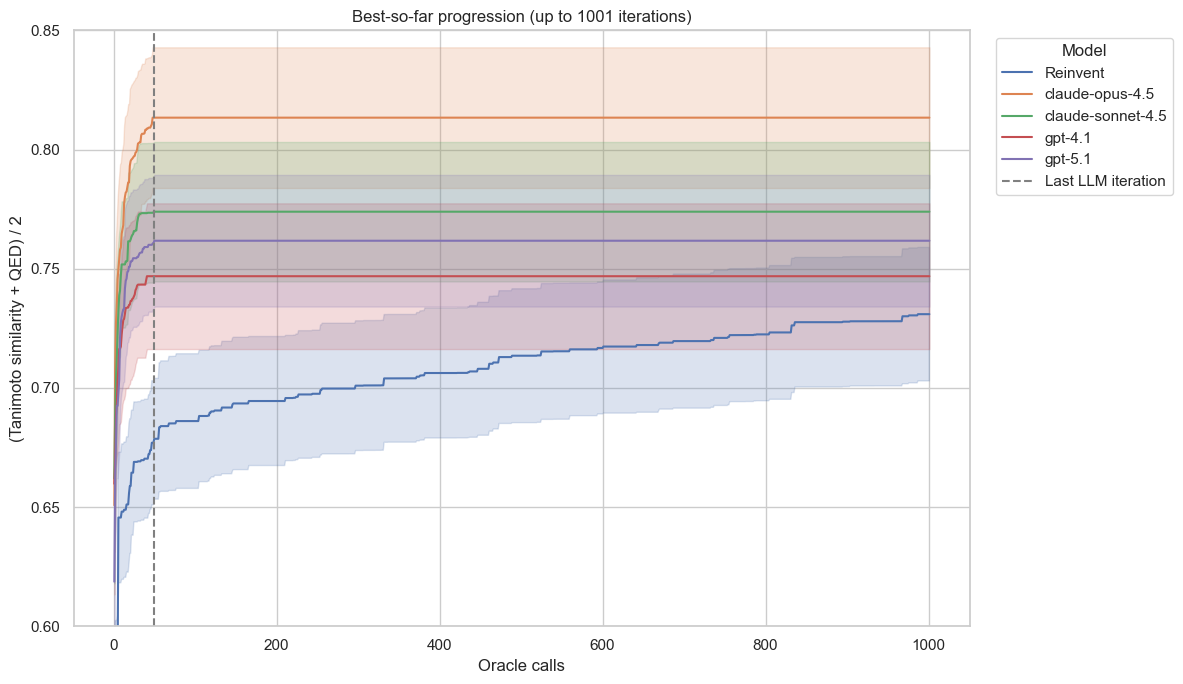

In [20]:
# Determine max iterations for Reinvent
max_reinvent_iter = df_reinvent["iteration"].max()
print(f"Max Reinvent iterations: {max_reinvent_iter}")

# Filter combined data to Reinvent iteration range
df_combined_limited = df_combined[df_combined["iteration"] <= max_reinvent_iter].copy()

# Pivot so each run is a column, forward-fill to handle runs ending early
all_iterations = range(1, max_reinvent_iter + 1)
df_plot_combined = (
    df_combined_limited.pivot_table(
        index="iteration", 
        columns=["model", "xai_mode", "target_molecule"], 
        values="best_so_far"
    )
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% CI, deterministic via SE * 1.96)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_plot_combined, x="iteration", y="value", hue="model", errorbar=('se', 1.96))
plt.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Last LLM iteration')
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.ylim(0.6, 0.85)
plt.xlabel("Oracle calls")
plt.title(f"Best-so-far progression (up to {max_reinvent_iter} iterations)")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

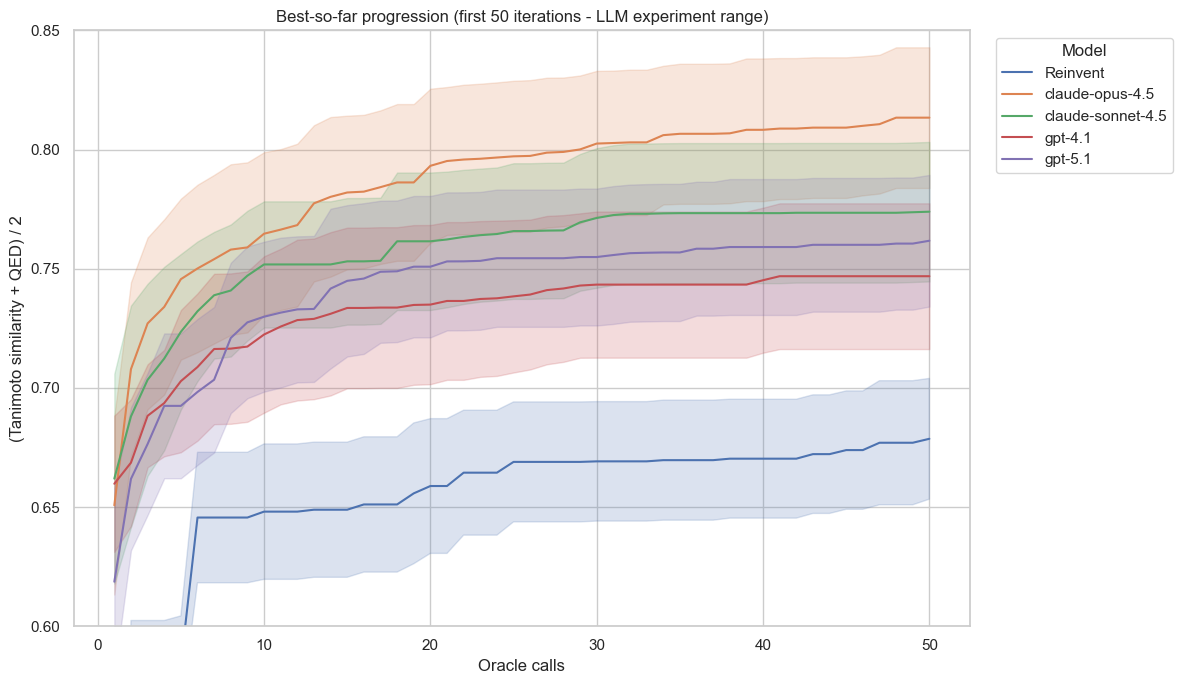

In [21]:
# Zoomed view: First 51 iterations (LLM experiment range)
max_llm_iter = 50
df_combined_zoomed = df_combined[df_combined["iteration"] <= max_llm_iter].copy()

all_iterations_zoomed = range(1, max_llm_iter + 1)
df_plot_zoomed = (
    df_combined_zoomed.pivot_table(
        index="iteration", 
        columns=["model", "xai_mode", "target_molecule"], 
        values="best_so_far"
    )
    .reindex(all_iterations_zoomed)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% CI, deterministic via SE * 1.96)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_plot_zoomed, x="iteration", y="value", hue="model", errorbar=('se', 1.96))
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlabel("Oracle calls")
plt.title("Best-so-far progression (first 50 iterations - LLM experiment range)")
plt.ylim(0.6, 0.85)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

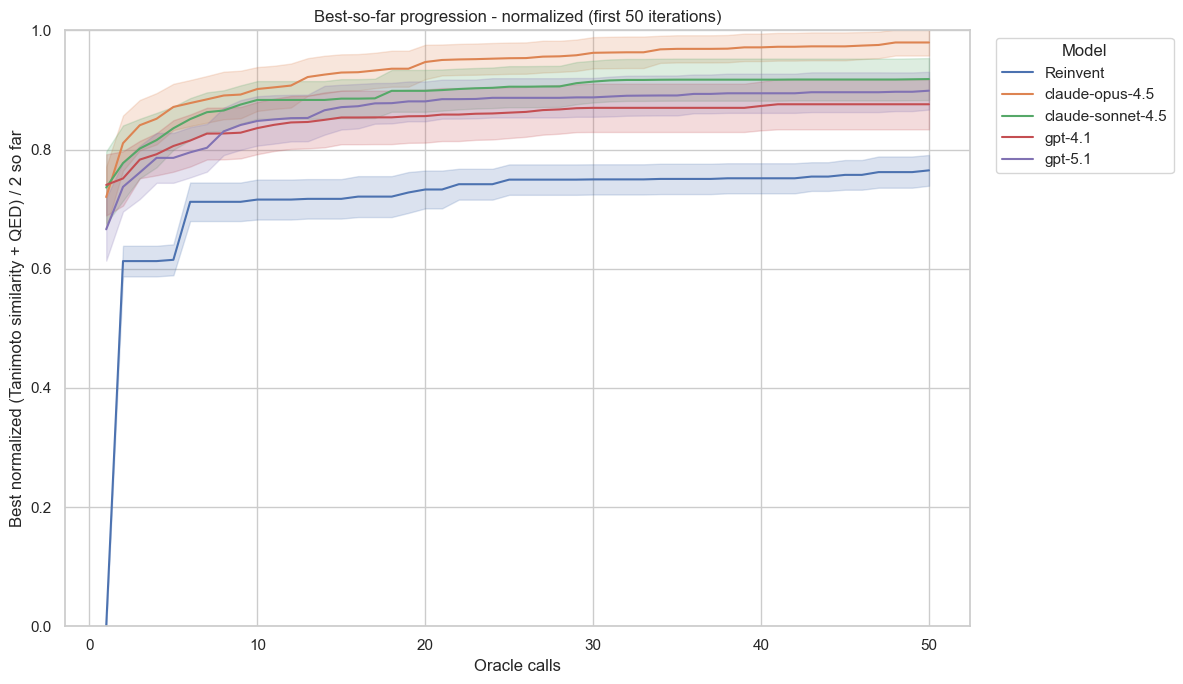

In [22]:
# Normalized zoomed view (first 50 iterations)
# Compute min and max of best_so_far for each target molecule (across all models)
target_stats_combined = df_combined.groupby("target_molecule")["best_so_far"].agg(["min", "max"])
target_stats_combined["range"] = target_stats_combined["max"] - target_stats_combined["min"]

df_norm_zoomed = df_combined_zoomed.copy()
df_norm_zoomed = df_norm_zoomed.merge(target_stats_combined, on="target_molecule")
df_norm_zoomed["best_so_far_normalized"] = (
    (df_norm_zoomed["best_so_far"] - df_norm_zoomed["min"]) / df_norm_zoomed["range"]
)

df_plot_norm_zoomed = (
    df_norm_zoomed.pivot_table(
        index="iteration", 
        columns=["model", "xai_mode", "target_molecule"], 
        values="best_so_far_normalized"
    )
    .reindex(all_iterations_zoomed)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% CI, deterministic via SE * 1.96)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_plot_norm_zoomed, x="iteration", y="value", hue="model", errorbar=('se', 1.96))
plt.ylabel("Best normalized (Tanimoto similarity + QED) / 2 so far")
plt.xlabel("Oracle calls")
plt.title("Best-so-far progression - normalized (first 50 iterations)")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Summary Statistics

### Iteration to reach 0.7 threshold (best-so-far)

In [23]:
# Find first iteration where best_so_far >= 0.7 threshold for each (model, target_molecule)
THRESHOLD = 0.7

def first_iteration_above_threshold(group, threshold=THRESHOLD):
    """Return first iteration where best_so_far >= threshold, or NaN if never reached."""
    above = group[group["best_so_far"] >= threshold]
    if len(above) > 0:
        return above["iteration"].min()
    return np.nan

# Compute for each model and target molecule
iter_to_threshold = (
    df_combined
    .groupby(["model", "target_molecule"])
    .apply(first_iteration_above_threshold, include_groups=False)
    .reset_index(name="iter_to_0.7")
)

# Summarize by model: mean and std
threshold_summary = (
    iter_to_threshold
    .groupby("model")["iter_to_0.7"]
    .agg(["mean", "std", "count", lambda x: x.isna().sum()])
    .rename(columns={"mean": "Mean Iteration", "std": "SD", "count": "N", "<lambda_0>": "Never Reached"})
)
threshold_summary["Success Rate"] = threshold_summary["N"] / 20 * 100
threshold_summary = threshold_summary.round(2)

print("Iteration to reach 0.7 threshold (best-so-far)")
threshold_summary

Iteration to reach 0.7 threshold (best-so-far)


,Mean Iteration,SD,N,Never Reached,Success Rate
model,,,,,
Reinvent,138.21,207.24,14,6,70.0
claude-opus-4.5,7.42,10.36,19,1,95.0
claude-sonnet-4.5,3.59,5.11,17,3,85.0
gpt-4.1,4.43,5.63,14,6,70.0
gpt-5.1,7.59,9.50,17,3,85.0


### Area Under Curve (AUC) - First 1000 iterations

In [24]:
# Compute AUC for first 1000 iterations using best_so_far
# We need to use the forward-filled data to handle different run lengths
MAX_ITER_AUC = 1000

# Pivot and forward-fill to get complete data for all iterations
all_iterations_auc = range(1, MAX_ITER_AUC + 1)
df_auc = (
    df_combined[df_combined["iteration"] <= MAX_ITER_AUC]
    .pivot_table(
        index="iteration", 
        columns=["model", "target_molecule"], 
        values="best_so_far"
    )
    .reindex(all_iterations_auc)
    .ffill()
)

# Compute AUC (sum of best_so_far values = area under step function)
# Each model-molecule combination is a column
auc_per_run = df_auc.sum()  # Sum over iterations for each column

# Convert to DataFrame for aggregation
auc_df = auc_per_run.reset_index()
auc_df.columns = ["model", "target_molecule", "AUC"]

# Summarize by model
auc_summary = (
    auc_df
    .groupby("model")["AUC"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "Mean AUC", "std": "SD"})
    .round(2)
)

print(f"AUC of best-so-far curve (first {MAX_ITER_AUC} iterations)")
auc_summary

AUC of best-so-far curve (first 1000 iterations)


,Mean AUC,SD
model,,
Reinvent,707.84,61.54
claude-opus-4.5,812.02,67.27
claude-sonnet-4.5,773.12,66.50
gpt-4.1,746.04,69.66
gpt-5.1,760.42,63.01
